# Comparing the Criterion Value
## Original Model vs Phi Specified Model 
### Education Level 2

## Dependencies, Packages & Roots

### Magics

In [1]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [2]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

## Load Data 

In [3]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level = "edu1"
# education_level = "edu2"
# education_level = "edu3"

#Number og simulations to run for each model when computing criterion values
n_sim = 100

education_level_file = pp.MOMENTS_DIR / f"moments_{education_level}.txt"

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / f"wage_params_{education_level}_ols.txt")

In [4]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], inplace=True)
# df_edu

# ====================================================================================================================

## Options for model - Choices and states

In [5]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "choices": labour_choices, # 5 choices
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1900,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount": 0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Initial values for simulating. 

In [6]:
# Select number of individuals for simulation
#Debug level
n_individuals = 10000

# Optimal level
# n_individuals = 250000

seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

### Define Criterion function for simulating across seeds

In [7]:
def criterion_by_moment(model_solved, seed, model_name=None):
    
    keep_cols = ["hours_0", "hours_1","hours_2","hours_3","hours_4", "work_work", "nowork_nowork"]

    # Simulate model
    sim = model_solved.simulate(
        states_initial=states_initial,
        seed=seed,
    )

    # Compute simulated moments
    sim_moments = compute_simulation_moments(sim, start_age, hours_map)

    # Empirical moments
    empirical_moms = df_edu.copy()

    # Drop pension column if present
    sim_moments = sim_moments.drop(columns=["pens"], errors="ignore")
    empirical_moms = empirical_moms.drop(columns=["pens"], errors="ignore")

    # Keep only selected moments
    sim_moments = sim_moments[keep_cols]
    empirical_moms = empirical_moms[keep_cols]

    # Check that shapes match
    if sim_moments.shape != empirical_moms.shape:
        raise ValueError(
            f"Shape mismatch: simulated moments have shape {sim_moments.shape}, "
            f"empirical moments have shape {empirical_moms.shape}"
        )

    # Convert to arrays
    sim_vals = sim_moments.to_numpy()
    emp_vals = empirical_moms.to_numpy()

    # Difference by age and moment
    diff = sim_vals - emp_vals

    epsilon = 1e-10

    # Same weighting logic as your current criterion
    emp_var = np.nanvar(emp_vals, axis=0, ddof=1)
    weights = 1.0 / (emp_var + epsilon)

    rows = []

    for i, moment in enumerate(keep_cols):
        squared_error_sum = np.nansum(diff[:, i] ** 2)
        criterion_contribution = weights[i] * squared_error_sum

        rows.append(
            {
                "model": model_name,
                "seed": seed,
                "moment": moment,
                "squared_error_sum": squared_error_sum,
                "empirical_variance": emp_var[i],
                "weight": weights[i],
                "criterion_value": criterion_contribution,
            }
        )

    out = pd.DataFrame(rows)

    total_criterion = out["criterion_value"].sum()
    out["total_criterion"] = total_criterion
    out["share_of_total_criterion"] = out["criterion_value"] / total_criterion

    return out


### Define fixed seeds for both models

In [8]:
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=n_sim)

## New model

### Load params, solve model and simulate juts once

In [9]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"optimized_params_phi_{education_level}.txt")
params["gamma"] = jnp.asarray(params["gamma"])

In [10]:
new_model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=new_utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



In [11]:
new_model_solved = new_model.solve(params)
new_model.validate_exogenous(params)

True

### Running the criterion value across {n_sim} seeds for my model

In [12]:
new_model_results = []

for i, seed in enumerate(seeds):
    seed = int(seed)

    crit_by_moment = criterion_by_moment(
        new_model_solved,
        seed,
        model_name=f"new_model_{education_level}",
    )

    crit_by_moment["run"] = i + 1

    total_criterion = crit_by_moment["total_criterion"].iloc[0]

    print(
        f"Run {i+1:03d} | Seed: {seed} | "
        f"Criterion value: {total_criterion:.6f}"
    )

    new_model_results.append(crit_by_moment)

new_model_crit_table = pd.concat(
    new_model_results,
    ignore_index=True,
)

new_model_crit_table

Run 001 | Seed: 1501552845 | Criterion value: 228.326985
Run 002 | Seed: 488200390 | Criterion value: 230.508028
Run 003 | Seed: 1693606510 | Criterion value: 230.192798
Run 004 | Seed: 680233354 | Criterion value: 218.824707
Run 005 | Seed: 438466540 | Criterion value: 239.350755
Run 006 | Seed: 1712329280 | Criterion value: 240.319542
Run 007 | Seed: 1380152455 | Criterion value: 241.025838
Run 008 | Seed: 1452245846 | Criterion value: 227.445716
Run 009 | Seed: 2122694021 | Criterion value: 234.626064
Run 010 | Seed: 839901363 | Criterion value: 232.286950
Run 011 | Seed: 1802651552 | Criterion value: 233.351346
Run 012 | Seed: 714712467 | Criterion value: 227.715702
Run 013 | Seed: 1218704077 | Criterion value: 235.468903
Run 014 | Seed: 1284858263 | Criterion value: 220.534672
Run 015 | Seed: 457721135 | Criterion value: 227.372352
Run 016 | Seed: 401008609 | Criterion value: 242.781095
Run 017 | Seed: 492064534 | Criterion value: 236.990888
Run 018 | Seed: 1444732602 | Criterion 

,model,seed,moment,squared_error_sum,empirical_variance,weight,criterion_value,total_criterion,share_of_total_criterion,run
0,new_model_edu1,1501552845,hours_0,0.666300,0.093837,10.656734,7.100583,228.326985,0.031098,1
1,new_model_edu1,1501552845,hours_1,0.036445,0.000377,2649.209160,96.551433,228.326985,0.422865,1
2,new_model_edu1,1501552845,hours_2,0.046403,0.000660,1514.262951,70.266865,228.326985,0.307747,1
3,new_model_edu1,1501552845,hours_3,0.047330,0.001229,813.867913,38.520034,228.326985,0.168706,1
4,new_model_edu1,1501552845,hours_4,0.129606,0.061083,16.371279,2.121812,228.326985,0.009293,1
...,...,...,...,...,...,...,...,...,...,...
695,new_model_edu1,1349917978,hours_2,0.048501,0.000660,1514.262951,73.443661,236.264552,0.310853,100
696,new_model_edu1,1349917978,hours_3,0.047413,0.001229,813.867913,38.587979,236.264552,0.163325,100
697,new_model_edu1,1349917978,hours_4,0.117329,0.061083,16.371279,1.920822,236.264552,0.008130,100
698,new_model_edu1,1349917978,work_work,0.225999,0.086571,11.551266,2.610580,236.264552,0.011049,100


In [13]:
new_model_crit_table.to_csv(
    pp.STRUCTURAL_RESULTS_DIR / f"new_model_criterion_by_moment_{education_level}.csv",
    index=False,
)

## Old model

### Load params, solve model and simulate juts once

In [14]:
params_old = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"original_params_{education_level}.txt")
params_old["gamma"] = jnp.asarray(params_old["gamma"])

In [15]:
old_model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=old_utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



In [16]:
old_model_solved = old_model.solve(params_old)
old_model.validate_exogenous(params_old)

True

### Running the criterion value across 100 seeds for Larsen model

In [17]:
old_model_results = []

for i, seed in enumerate(seeds):
    seed = int(seed)

    crit_by_moment = criterion_by_moment(
        old_model_solved,
        seed,
        model_name=f"old_model_{education_level}",
    )

    crit_by_moment["run"] = i + 1

    total_criterion = crit_by_moment["total_criterion"].iloc[0]

    print(
        f"Run {i+1:03d} | Seed: {seed} | "
        f"Criterion value: {total_criterion:.6f}"
    )

    old_model_results.append(crit_by_moment)

old_model_crit_table = pd.concat(
    old_model_results,
    ignore_index=True,
)

old_model_crit_table

old_model_crit_table.to_csv(
    pp.STRUCTURAL_RESULTS_DIR / f"old_model_criterion_by_moment_{education_level}.csv",
    index=False,
)

Run 001 | Seed: 1501552845 | Criterion value: 335.017272
Run 002 | Seed: 488200390 | Criterion value: 332.307757
Run 003 | Seed: 1693606510 | Criterion value: 338.897372
Run 004 | Seed: 680233354 | Criterion value: 320.097396
Run 005 | Seed: 438466540 | Criterion value: 341.731661
Run 006 | Seed: 1712329280 | Criterion value: 340.918043
Run 007 | Seed: 1380152455 | Criterion value: 337.264894
Run 008 | Seed: 1452245846 | Criterion value: 332.589777
Run 009 | Seed: 2122694021 | Criterion value: 339.636599
Run 010 | Seed: 839901363 | Criterion value: 334.618578
Run 011 | Seed: 1802651552 | Criterion value: 340.021232
Run 012 | Seed: 714712467 | Criterion value: 331.188772
Run 013 | Seed: 1218704077 | Criterion value: 338.544796
Run 014 | Seed: 1284858263 | Criterion value: 330.414515
Run 015 | Seed: 457721135 | Criterion value: 326.150765
Run 016 | Seed: 401008609 | Criterion value: 345.694506
Run 017 | Seed: 492064534 | Criterion value: 342.067258
Run 018 | Seed: 1444732602 | Criterion 

### Plot the results from both runs

In [18]:
old_total_crit_table = (
    old_model_crit_table
    .groupby(["run", "seed", "model"], as_index=False)
    .agg(total_criterion=("total_criterion", "first"))
)

new_total_crit_table = (
    new_model_crit_table
    .groupby(["run", "seed", "model"], as_index=False)
    .agg(total_criterion=("total_criterion", "first"))
)

old_vals = old_total_crit_table["total_criterion"]
new_vals = new_total_crit_table["total_criterion"]

summary_table = pd.DataFrame({
    "model": ["old", "new"],
    "mean": [old_vals.mean(), new_vals.mean()],
    "median": [old_vals.median(), new_vals.median()],
    "std": [old_vals.std(), new_vals.std()],
    "min": [old_vals.min(), new_vals.min()],
    "max": [old_vals.max(), new_vals.max()],
})

summary_table

,model,mean,median,std,min,max
0,old,334.456361,334.467581,6.044254,320.097396,349.493183
1,new,232.249865,231.727788,5.418538,218.824707,242.913515


In [19]:
np.savez(
    pp.COMP_PLOTS_DIR / f"criterion_values_{education_level}_{n_sim}sim.npz",
    old_vals=old_vals.to_numpy(),
    new_vals=new_vals.to_numpy(),
)

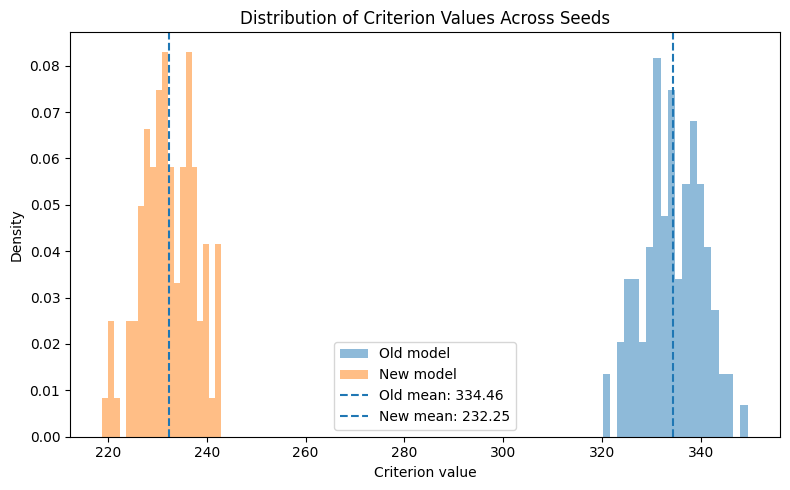

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    old_vals,
    bins=20,
    alpha=0.5,
    density=True,
    label="Old model",
)

plt.hist(
    new_vals,
    bins=20,
    alpha=0.5,
    density=True,
    label="New model",
)

plt.axvline(old_vals.mean(), linestyle="--", label=f"Old mean: {old_vals.mean():.2f}")
plt.axvline(new_vals.mean(), linestyle="--", label=f"New mean: {new_vals.mean():.2f}")

plt.xlabel("Criterion value")
plt.ylabel("Density")
plt.title("Distribution of Criterion Values Across Seeds")
plt.legend()
plt.tight_layout()
plt.show()

================================================================

# Comparison moment-level criterion values


In [21]:
# def compare_criterion_by_moment(
#     old_model_solved,
#     new_model_solved,
#     seed,
#     df_edu,
#     states_initial,
#     start_age,
#     hours_map,
#     keep_cols=None,
# ):
#     old_df = criterion_by_moment(
#         model_solved=old_model_solved,
#         seed=seed,
#         df_edu=df_edu,
#         states_initial=states_initial,
#         start_age=start_age,
#         hours_map=hours_map,
#         keep_cols=keep_cols,
#         model_name="Old model: 1 phi",
#     )

#     new_df = criterion_by_moment(
#         model_solved=new_model_solved,
#         seed=seed,
#         df_edu=df_edu,
#         states_initial=states_initial,
#         start_age=start_age,
#         hours_map=hours_map,
#         keep_cols=keep_cols,
#         model_name="New model: 3 phi",
#     )

#     comparison = old_df.merge(
#         new_df,
#         on="moment",
#         suffixes=("_old", "_new"),
#     )

#     comparison["criterion_old"] = comparison["criterion_value_old"]
#     comparison["criterion_new"] = comparison["criterion_value_new"]

#     comparison["absolute_change"] = (
#         comparison["criterion_new"] - comparison["criterion_old"]
#     )

#     comparison["absolute_reduction"] = (
#         comparison["criterion_old"] - comparison["criterion_new"]
#     )

#     comparison["percent_reduction"] = (
#         comparison["absolute_reduction"] / comparison["criterion_old"]
#     ) * 100

#     total_old = comparison["criterion_old"].sum()
#     total_new = comparison["criterion_new"].sum()
#     total_reduction = total_old - total_new

#     comparison["old_share_of_total"] = comparison["criterion_old"] / total_old
#     comparison["new_share_of_total"] = comparison["criterion_new"] / total_new

#     comparison["share_of_total_reduction"] = (
#         comparison["absolute_reduction"] / total_reduction
#     ) * 100

#     comparison = comparison[
#         [
#             "moment",
#             "criterion_old",
#             "criterion_new",
#             "absolute_reduction",
#             "percent_reduction",
#             "share_of_total_reduction",
#             "old_share_of_total",
#             "new_share_of_total",
#         ]
#     ]

#     comparison = comparison.sort_values(
#         "share_of_total_reduction",
#         ascending=False,
#     )

#     return comparison

In [22]:
# moment_comparison = compare_criterion_by_moment(
#     old_model_solved=old_model_solved,
#     new_model_solved=new_model_solved,
#     seed=seed,
#     df_edu=df_edu,
#     states_initial=states_initial,
#     start_age=start_age,
#     hours_map=hours_map,
# )

# moment_comparison

### Calculated the dataframes for each models moment-specific 

In [23]:
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# seeds = np.arange(100)

# all_moment_comparisons = []

# for s in tqdm(seeds):
#     moment_comparison_s = compare_criterion_by_moment(
#         old_model_solved=old_model_solved,
#         new_model_solved=new_model_solved,
#         seed=int(s),
#         df_edu=df_edu,
#         states_initial=states_initial,
#         start_age=start_age,
#         hours_map=hours_map,
#     )

#     moment_comparison_s["seed"] = int(s)

#     all_moment_comparisons.append(moment_comparison_s)

# moment_comparisons_all = pd.concat(
#     all_moment_comparisons,
#     ignore_index=True,
# )

# moment_comparisons_all

### Compare the two models moment-specific criterion values for 100 seeds pr model

In [24]:
# avg_moment_comparison = (
#     moment_comparisons_all
#     .groupby("moment", as_index=False)
#     .agg(
#         criterion_old_mean=("criterion_old", "mean"),
#         criterion_old_std=("criterion_old", "std"),
#         criterion_new_mean=("criterion_new", "mean"),
#         criterion_new_std=("criterion_new", "std"),
#         absolute_reduction_mean=("absolute_reduction", "mean"),
#         absolute_reduction_std=("absolute_reduction", "std"),
#     )
# )

# avg_moment_comparison["percent_reduction"] = (
#     avg_moment_comparison["absolute_reduction_mean"]
#     / avg_moment_comparison["criterion_old_mean"]
# ) * 100

# total_old = avg_moment_comparison["criterion_old_mean"].sum()
# total_new = avg_moment_comparison["criterion_new_mean"].sum()
# total_reduction = total_old - total_new

# avg_moment_comparison["old_share_of_total"] = (
#     avg_moment_comparison["criterion_old_mean"] / total_old
# )

# avg_moment_comparison["new_share_of_total"] = (
#     avg_moment_comparison["criterion_new_mean"] / total_new
# )

# avg_moment_comparison["share_of_total_reduction"] = (
#     avg_moment_comparison["absolute_reduction_mean"]
#     / total_reduction
# ) * 100

# avg_moment_comparison = avg_moment_comparison.sort_values(
#     "share_of_total_reduction",
#     ascending=False,
# )

# avg_moment_comparison